In [1]:
## DATA LOADING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("wine.csv")   
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [2]:
## Exploratory Data Analysis (EDA)
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [3]:
## Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_data[:5]

array([[-1.21394365,  1.51861254, -0.5622498 ,  0.23205254, -1.16959318,
         1.91390522,  0.80899739,  1.03481896, -0.65956311,  1.22488398,
         0.25171685,  0.36217728,  1.84791957,  1.01300893],
       [-1.21394365,  0.24628963, -0.49941338, -0.82799632, -2.49084714,
         0.01814502,  0.56864766,  0.73362894, -0.82071924, -0.54472099,
        -0.29332133,  0.40605066,  1.1134493 ,  0.96524152],
       [-1.21394365,  0.19687903,  0.02123125,  1.10933436, -0.2687382 ,
         0.08835836,  0.80899739,  1.21553297, -0.49840699,  2.13596773,
         0.26901965,  0.31830389,  0.78858745,  1.39514818],
       [-1.21394365,  1.69154964, -0.34681064,  0.4879264 , -0.80925118,
         0.93091845,  2.49144552,  1.46652465, -0.98187536,  1.03215473,
         1.18606801, -0.42754369,  1.18407144,  2.33457383],
       [-1.21394365,  0.29570023,  0.22769377,  1.84040254,  0.45194578,
         1.28198515,  0.80899739,  0.66335127,  0.22679555,  0.40140444,
        -0.31927553,  0.36

In [4]:
## Applying PCA
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(scaled_data)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.39542486, 0.17836259, 0.10329102, 0.06627984, 0.06267875,
       0.0480556 , 0.03955707, 0.02500244, 0.02103871, 0.01873615,
       0.01613203, 0.01205691, 0.00925458, 0.00412945])

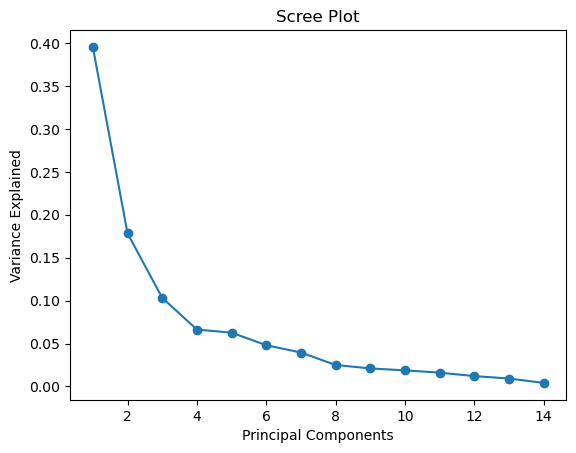

In [5]:
## Scree Plot
plt.plot(range(1,len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.title("Scree Plot")
plt.show()

In [6]:
## Final PCA Model
pca_final = PCA(n_components=2)
pca_data = pca_final.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=["PC1","PC2"])
pca_df.head()

,PC1,PC2
0,-3.522934,-1.453098
1,-2.528858,0.330019
2,-2.785029,-1.036936
3,-3.922588,-2.768210
4,-1.407511,-0.867773


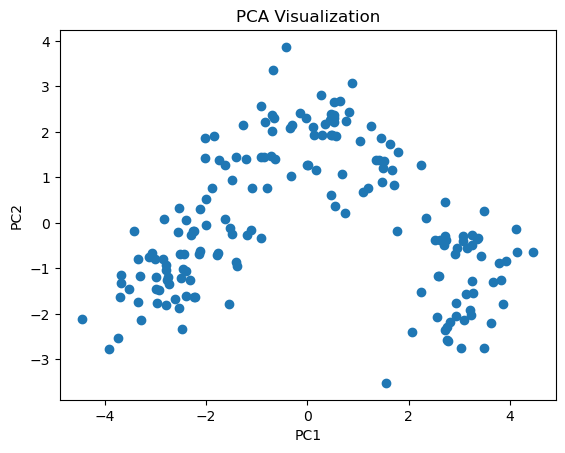

In [7]:
## PCA Visualization
plt.scatter(pca_df["PC1"], pca_df["PC2"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

## Conclusion 

PCA was applied to reduce dataset dimensionality while retaining maximum variance.  
The scree plot showed that first few components explained most variance.  
Thus PCA simplifies data and improves model efficiency.